In [2]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import pandas as pd
import numpy as np

from skfda.representation.basis import Fourier, BSpline
from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth
from skfda import FDataGrid

import matplotlib.pyplot as plt

from src.config import DATA, IMAGES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


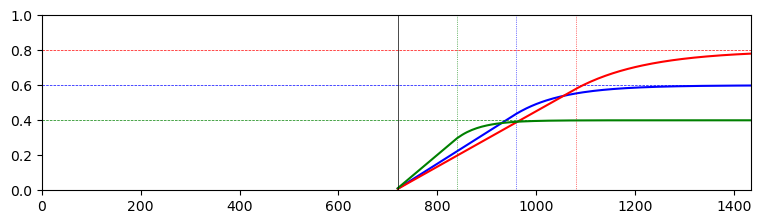

In [58]:
def linear_inverse_exponential(
    s_, 
    T_minutes, 
    nu_minutes, 
    sigma, 
    dt,
    eta = 2.5, 
    alpha = 1.
):

    u_ = 2.5*(s_[0] - s_ - dt + nu_minutes)/nu_minutes
        
    ELU_ = np.where(
        s_ > s_[0] + nu_minutes, 
        alpha * (np.exp(u_) - 1),
        u_, 
    )
    
    return sigma*((eta - ELU_) / (eta + alpha))

t = 144
dt = 5
T = 288

s_ = np.linspace(0, T*dt - dt, T)[t:]



_fig, _ax = plt.subplots(figsize=(7.5, 2.125), 
                         constrained_layout=True)

nu = 4
trust_rate = 0.6
eta = 2.5
y_ = linear_inverse_exponential(
    s_, 
    T_minutes = T*dt, 
    nu_minutes = nu*60,
    sigma = trust_rate,
    eta = eta,
    dt=dt,
)

plt.plot(s_, y_, color = 'b')

plt.axhline(trust_rate, 
            color='b', 
            lw = .5,
            linestyle='--', 
            label=f'trust_rate = {trust_rate}')

plt.axvline(t*dt + nu*60, 
            color='b', 
            lw = .5,
            linestyle=':')

nu = 6
trust_rate = 0.8
y_ = linear_inverse_exponential(
    s_, 
    T_minutes = T*dt, 
    nu_minutes = nu*60,
    sigma = trust_rate,
    eta = eta,
    dt=dt,
)

plt.plot(s_, y_, color = 'r')

plt.axhline(trust_rate, 
            color='r', 
            lw = .5,
            linestyle='--')

plt.axvline(t*dt + nu*60, 
            color='r', 
            lw = .5,
            linestyle=':')

nu = 2
trust_rate = 0.4
y_ = linear_inverse_exponential(
    s_, 
    T_minutes = T*dt, 
    nu_minutes = nu*60,
    sigma = trust_rate,
    eta = eta,
    dt=dt,
)

plt.plot(s_, y_, color = 'g')

plt.axhline(trust_rate, 
            color='g', 
            lw = .5,
            linestyle='--')

plt.axvline(t*dt + nu*60, 
            color='g', 
            lw = .5,
            linestyle=':')


plt.axvline(t*dt, 
            color='k', 
            lw = .5)

plt.ylim(0, 1)
plt.xlim(0, T*dt - 5)

plt.savefig(IMAGES / f"LIE.pdf")

plt.show()

165
122
125
144


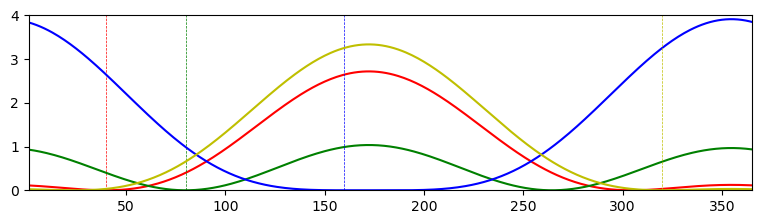

In [67]:
# --- seasonal membership ---

# Periodic distance to rank samples by day of the year
def _periodic_dist(d_star, 
                   period = 1.,
                   day_to_degree = 360/365, 
                   degree_to_rad = np.pi/180):

    return np.sin(period*degree_to_rad*day_to_degree*d_star)

# Solstice day of the year: 172 (summer), and 355 (winter)
# Equinox day of the year: 80 (spring), and 266 (fall)
def _equinox_dist(d1, d2, d_prime, thr):

    if d_prime < thr:
        return _periodic_dist(d1, d2, alpha = 1)
    else:
        return _periodic_dist(d1, d2, alpha = 0.5)    
        
# Equinoxes - Solstices seasonal distance
def seasonal_equinox_dist(d1, d2, 
                          rho = None, 
                          thr = 25, 
                          scale = 2):

    d_prime_spring = np.absolute(80 - d2)
    d_prime_fall = np.absolute(266 - d2)
    
    d_prime = np.min([d_prime_spring, d_prime_fall]) 
    print(d_prime)
    if rho is None:
        return _equinox_dist(d1, d2, d_prime, thr)
        
    else:
        window = np.absolute(rho - (d_prime/scale))
        print(d2, window)
        return _equinox_dist(d1, d2, d_prime, thr)

def _solar_declination(d_star, day_to_degree = 360/365, degree_to_rad = np.pi/180):
    # δ(d∗)=23.45∘⋅sin(365360∘(284+d∗))
    return np.sin(degree_to_rad*day_to_degree*(284 + d_star))


def seasonal_distance(d_, d_star):

    r_ = (_solar_declination(d_) - _solar_declination(d_star))**2
    return r_


d_ = np.linspace(0, 364, 365) + 1

rho = 0.25

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), 
                         constrained_layout=True)

d_star = 40
r_ = seasonal_distance(d_, d_star)
print((r_ < rho).sum())

plt.plot(d_, r_, color = 'r')

plt.axvline(d_star, 
            color='r', 
            lw = .5,
            linestyle='--', 
            label=f'$d_{{\star}}$ = {d_star}')

d_star = 80
r_ = seasonal_distance(d_, d_star)
print((r_ < rho).sum())

plt.plot(d_, r_, color = 'g')

plt.axvline(d_star, 
            color='g', 
            lw = .5,
            linestyle='--', 
            label=f'$d_{{\star}}$ = {d_star}')

d_star = 160
r_ = seasonal_distance(d_, d_star)
print((r_ < rho).sum())

plt.plot(d_, r_, color = 'b')

plt.axvline(d_star, 
            color='b', 
            lw = .5,
            linestyle='--', 
            label=f'$d_{{\star}}$ = {d_star}')

d_star = 320
r_ = seasonal_distance(d_, d_star)
print((r_ < rho).sum())

plt.plot(d_, r_, color = 'y')

plt.axvline(d_star, 
            color='y', 
            lw = .5,
            linestyle='--', 
            label=f'$d_{{\star}}$ = {d_star}')

# plt.axhline(0.1, 
#             color='k', 
#             lw = 1.,
#             linestyle=':', 
#             label=f'$d_{{\star}}$ = {d_star}')

plt.xlim(1, 365)
plt.ylim(0, 4)

plt.savefig(IMAGES / f"SED.pdf")

plt.show()

172.0 355.0


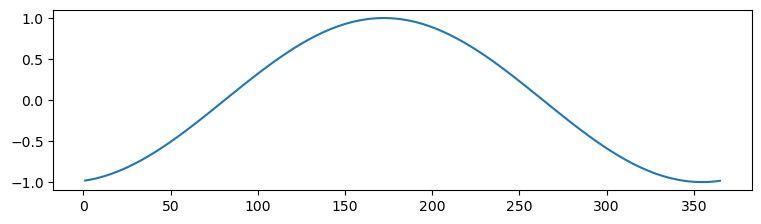

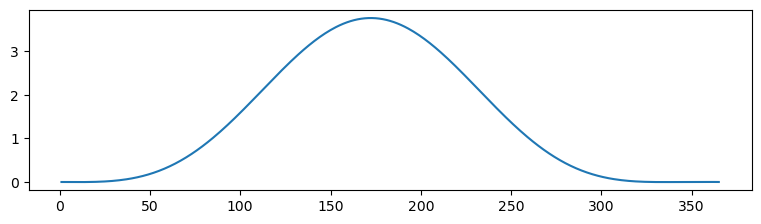

In [73]:
# --- seasonal membership ---

# Periodic distance to rank samples by day of the year
def _periodic_dist(d_star, 
                   period = 1.,
                   day_to_degree = 360/365, 
                   degree_to_rad = np.pi/180):

    return np.sin(period*degree_to_rad*day_to_degree*d_star)

# Solstice day of the year: 172 (summer), and 355 (winter)
# Equinox day of the year: 80 (spring), and 266 (fall)
def _equinox_dist(d1, d2, d_prime, thr):

    if d_prime < thr:
        return _periodic_dist(d1, d2, alpha = 1)
    else:
        return _periodic_dist(d1, d2, alpha = 0.5)    
        
# Equinoxes - Solstices seasonal distance
def seasonal_equinox_dist(d1, d2, 
                          rho = None, 
                          thr = 25, 
                          scale = 2):

    d_prime_spring = np.absolute(80 - d2)
    d_prime_fall = np.absolute(266 - d2)
    
    d_prime = np.min([d_prime_spring, d_prime_fall]) 
    print(d_prime)
    if rho is None:
        return _equinox_dist(d1, d2, d_prime, thr)
        
    else:
        window = np.absolute(rho - (d_prime/scale))
        print(d2, window)
        return _equinox_dist(d1, d2, d_prime, thr)

def _solar_declination(d_star, day_to_degree = 360/365, degree_to_rad = np.pi/180):
    # δ(d∗​)=23.45∘⋅sin(365360∘​(284+d∗​))
    return np.sin(degree_to_rad*day_to_degree*(284 + d_star))


def seasonal_distance_v1(d_, d_star):

    r_ = (_solar_declination(d_) - _solar_declination(d_star))**2

    # u = _solar_declination(d_star + rho)
    # l = _solar_declination(d_star - rho)

    return r_

d_star = 10
d_ = np.linspace(0, 364, 365) + 1

w_ = _solar_declination(d_)

print(d_[np.argmax(w_)], d_[np.argmin(w_)])

r_ = seasonal_distance_v1(d_, d_star)

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), 
                         constrained_layout=True)

plt.plot(d_, w_)
plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), 
                         constrained_layout=True)

plt.plot(d_, r_)
plt.show()

In [2]:
# Create the DataFrame
df_ = {
    'forget_rate_f': [0.1250, 0.0625, 0.0625],
    'forget_rate_e': [0.25, 1., 2.],
    'lookup_rate': [128., 128., 128.],
    'length_scale_f': [0.075, 0.05, 0.025],
    'length_scale_e': [0.1, 0.1, 0.1],
    'trust_rate': [0.1, 0.1, 0.2],
    'nu': [2., 1.5, 1.],
    'xi': [0.9, 0.9, 0.9],
    'gamma': [120, 110, 70],
    'kappa_min': [50, 75, 100],
    'kappa_max': [200, 100, 100],
}

# data = {
#     'forget_rate_f': [0.1250, 0.0625, 0.0625],
#     'forget_rate_e': [0.25, 1., 2.],
#     'lookup_rate': [128., 128., 128.],
#     'length_scale_f': [0.075, 0.05, 0.025],
#     'length_scale_e': [0.1, 0.1, 0.1],
#     'trust_rate': [0.1, 0.1, 0.2],
#     'nu': [2., 1.5, 1.],
#     'xi': [0.9, 0.9, 0.9],
#     'gamma': [120, 110, 70],
#     'kappa_min': [50, 75, 100],
#     'kappa_max': [200, 100, 100],
# }

# data = {
#     'forget_rate_f': [0.1250, 0.0625, 0.0625],
#     'forget_rate_e': [1., 1., 1.],
#     'lookup_rate': [128., 128., 128.],
#     'length_scale_f': [0.05, 0.05, 0.05],
#     'length_scale_e': [0.1, 0.1, 0.1],
#     'trust_rate': [0.15, 0.15, 0.15],
#     'nu': [1.5, 1.5, 1.5],
#     'xi': [0.9, 0.9, 0.9],
#     'gamma': [90, 90, 90],
#     'kappa_min': [75, 75, 75],
#     'kappa_max': [125, 125, 125],
# }


df_ = pd.DataFrame(df_, index = [72, 144, 216]).T
df_.to_csv(path_to_data + 'wind_dynamic_update_param.csv')

In [3]:
# Create the DataFrame
df_ = {
    'forget_rate_f': [0.0625, 0.0625, 0.0625],
    'forget_rate_e': [2., 2., 1.],
    'lookup_rate': [128., 256., 128.],
    'length_scale_f': [0.05, 0.05, 0.05],
    'length_scale_e': [0.025, 0.025, 0.075],
    'trust_rate': [0.5, 0.5, 0.2],
    'nu': [3., 4., 10.],
    'xi': [0.8, 0.8, 0.8],
    'gamma': [10, 30, 30],
    'kappa_min': [50, 25, 25],
    'kappa_max': [175, 125, 150],
}

# data = {
#     'forget_rate_f': [0.0625, 0.0625, 0.0625],
#     'forget_rate_e': [.5, .5, .5],
#     'lookup_rate': [20., 20., 20.],
#     'length_scale_f': [0.025, 0.025, 0.025],
#     'length_scale_e': [0.05, 0.05, 0.05],
#     'trust_rate': [0.25, 0.25, 0.25],
#     'nu': [4., 4., 4.],
#     'xi': [0.8, 0.8, 0.8],
#     'gamma': [30, 30, 30],
#     'kappa_min': [25, 25, 25],
#     'kappa_max': [150, 150, 150]
# }

df_ = pd.DataFrame(df_, index = [120, 144, 168]).T
df_.to_csv(path_to_data + 'solar_dynamic_update_param.csv')

In [4]:
file_name = 'wind_dynamic_update_param.csv'

df_ = pd.read_csv(path_to_data + file_name)
df_.rename(columns = {'Unnamed: 0': 'hyperparameter'}, inplace = True)
print(df_)

t_      = df_.columns[1:].to_numpy().astype(int)
t_star_ = np.linspace(t_[0], t_[-1], t_[-1] - t_[0] + 1, dtype = int)

dfs_ = []
for i in range(df_.shape[0]):
    
    name = df_.loc[i].to_numpy()[0]
    x_   = df_.loc[i].to_numpy()[1:].T
    x_   = x_.astype(float)
    
    _fd        = FDataGrid(data_matrix = [x_], grid_points = t_)
    _fd_interp = _fd.to_basis(BSpline(n_basis = 4))
    x_star_    = _fd_interp.to_grid(t_star_).data_matrix[0][:, 0] 

    dfs_.append([name] + list(x_star_))

dfs_ = pd.DataFrame(np.stack(dfs_) , columns = ['hyperparameter'] + list(t_star_))
dfs_ = dfs_.set_index(dfs_.columns[0])

dfs_.to_csv(path_to_data + 'interp_' + file_name, index = True)
dfs_ = pd.read_csv(path_to_data + 'interp_' + file_name, index_col = 0)
print(dfs_)

    hyperparameter       72       144       216
0    forget_rate_f    0.125    0.0625    0.0625
1    forget_rate_e    0.250    1.0000    2.0000
2      lookup_rate  128.000  128.0000  128.0000
3   length_scale_f    0.075    0.0500    0.0250
4   length_scale_e    0.100    0.1000    0.1000
5       trust_rate    0.100    0.1000    0.2000
6               nu    2.000    1.5000    1.0000
7               xi    0.900    0.9000    0.9000
8            gamma  120.000  110.0000   70.0000
9        kappa_min   50.000   75.0000  100.0000
10       kappa_max  200.000  100.0000  100.0000
                     72          73          74          75          76  \
hyperparameter                                                            
forget_rate_f     0.125    0.123491    0.122004    0.120537    0.119091   
forget_rate_e     0.250    0.264655    0.279109    0.293364    0.307426   
lookup_rate     128.000  128.000000  128.000000  128.000000  128.000000   
length_scale_f    0.075    0.074483    0.073973  